# DeepPermNet: Visual Permutation Learning

Welcome to this Jupyter Notebook, dedicated to simulating and reproducing the core concepts from the paper: **[DeepPermNet: Visual Permutation Learning](https://arxiv.org/abs/1704.02729)** by Rodrigo Santa Cruz, Basura Fernando, Anoop Cherian, and Stephen Gould.

## 📖 Paper Overview
Visual data contains rich spatial and temporal structure. This paper introduces a principled approach to uncover this structure by solving a novel deep learning task: **Visual Permutation Learning**. The primary objective is to find the permutation matrix that can recover the original structure of data from its shuffled versions (e.g., reassembling a natural image from scrambled image patches).

Since standard permutation matrices are discrete and difficult to optimize with gradient-based methods, the authors propose **DeepPermNet**. This end-to-end Convolutional Neural Network (CNN) approximates these matrices using a continuous **Sinkhorn layer**, which generates doubly-stochastic matrices via Sinkhorn iterations to enable efficient backpropagation.

## 🎯 Notebook Objectives
In this notebook, we will:
1. **Prepare the data**: use mini-imagenet to construct for the dataset for the following training process.
2. **Understand the Architecture:** Build the Siamese-style CNN that extracts features from permuted image sequences.
3. **Implement the Sinkhorn Layer:** Create the custom differentiable layer that repeatedly performs row and column normalizations to approximate permutation matrices.
4. **Train the Model:** Use a lightweight dataset to train the network in a self-supervised manner, utilizing spatial layout as the supervisory signal.
5. **Evaluate:** Visualize the model's ability to predict the correct permutation and "un-shuffle" patches to recover the original image layout.



# Data preparation

While the original paper relies on datasets like the *Public Figures dataset*, *OSR scene dataset*, and the massive full *ImageNet* for various tasks, we will utilize a smaller, memory-friendly variant like **Mini-ImageNet** (via `timm/mini-imagenet`). This ensures the notebook runs smoothly in compute-constrained environments like Google Colab while maintaining enough complexity for robust self-supervised representation learning.

## Packages installing

In [20]:
!pip install onnxscript onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 12.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 14.3 MB/s eta 0:00:00


## Load data

In [ ]:
import os
HF_TOKEN = ""

os.environ["HF_TOKEN"] = HF_TOKEN

In [7]:
from datasets import load_dataset

ds = load_dataset("timm/mini-imagenet")

data/train-00000-of-00013.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

data/train-00001-of-00013.parquet:   0%|          | 0.00/361M [00:00<?, ?B/s]

data/train-00002-of-00013.parquet:   0%|          | 0.00/410M [00:00<?, ?B/s]

data/train-00003-of-00013.parquet:   0%|          | 0.00/452M [00:00<?, ?B/s]

data/train-00004-of-00013.parquet:   0%|          | 0.00/395M [00:00<?, ?B/s]

...

data/test-00000-of-00002.parquet:   0%|          | 0.00/326M [00:00<?, ?B/s]

data/test-00001-of-00002.parquet:   0%|          | 0.00/336M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5000 [00:00<?, ? examples/s]

--- Dataset Dictionary Structure ---
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 50000
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 5000
    })
})

--- Features in the Training Split ---
{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['n01532829', 'n01558993', 'n01704323', 'n01749939', 'n01770081', 'n01843383', 'n01855672', 'n01910747', 'n01930112', 'n01981276', 'n02074367', 'n02089867', 'n02091244', 'n02091831', 'n02099601', 'n02101006', 'n02105505', 'n02108089', 'n02108551', 'n02108915', 'n02110063', 'n02110341', 'n02111277', 'n02113712', 'n02114548', 'n02116738', 'n02120079', 'n02129165', 'n02138441', 'n02165456', 'n02174001', 'n02219486', 'n02443484', 'n02457408', 'n02606052', 'n02687172', 'n02747177', 'n02795169', 'n02823428', 'n02871525', 'n02950826', 'n02966193', 'n02971356', 'n0298

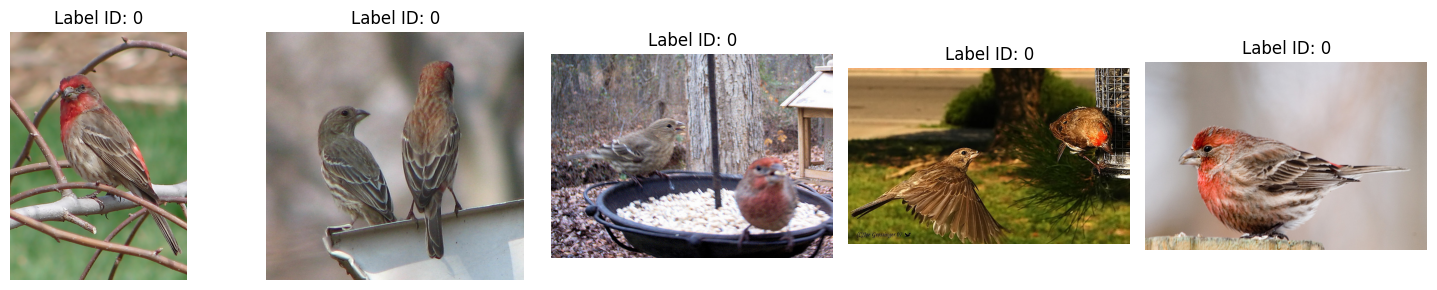

In [8]:
import matplotlib.pyplot as plt

print("--- Dataset Dictionary Structure ---")
print(ds)

# Let's look specifically at the 'train' split
train_ds = ds['train']
print("\n--- Features in the Training Split ---")
print(train_ds.features)

# Showcase sample images
num_samples = 5
# Create a figure with 1 row and 5 columns
fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))

for i in range(num_samples):
    # Extract the PIL image and the label from the dataset
    img = train_ds[i]['image']
    label_id = train_ds[i]['label']

    # Plot the image
    axes[i].imshow(img)
    axes[i].set_title(f"Label ID: {label_id}")
    axes[i].axis('off') # Hide the axes for a cleaner look

plt.tight_layout()
plt.show()

## Shuffling

In this section, we construct the self-supervised dataset required to train **DeepPermNet**. Since our goal is to teach the model to "un-shuffle" images, we don't need traditional class labels. Instead, we use the inherent spatial structure of the images themselves.

Using **PyTorch Lightning**, we build a robust data pipeline that performs the following steps on the fly for every image in the Mini-ImageNet dataset:

1. **Resize & Normalize:** Each image is resized to $192 \times 192$ pixels to ensure uniform dimensions.
2. **Grid Splitting:** The image is divided into a $3 \times 3$ grid, extracting nine $64 \times 64$ pixel patches.
3. **Random Permutation (The Shuffle):** A random sequence (from 0 to 8) is generated and used to shuffle the spatial order of the nine patches.
4. **Target Generation:** The shuffled patches become our input features ($X$), and the specific permutation array used to shuffle them becomes our target label ($Y$).

By the end of this section, we will have a fully functional `LightningDataModule` ready to feed batches of scrambled image patches into our neural network.

In [9]:
import torch
import pytorch_lightning as pl
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import random
from datasets import load_dataset
import matplotlib.pyplot as plt

class DeepPermNetDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset

        # To perfectly simulate the 3x3 grid of 64x64 patches,
        # we ensure the base image is 192x192 pixels.
        self.base_transform = transforms.Compose([
            transforms.Resize((192, 192)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        # 1. Get image and ensure it's RGB
        img = self.hf_dataset[idx]['image']
        if img.mode != 'RGB':
            img = img.convert('RGB')

        # 2. Apply base transform to get a 3x192x192 tensor
        img_tensor = self.base_transform(img)

        # 3. Extract the 3x3 grid of 64x64 patches
        # We use tensor unfolding to cleanly slice the image into patches
        # Shape: (Channels, Grid_H, Grid_W, Patch_H, Patch_W) -> (3, 3, 3, 64, 64)
        patches = img_tensor.unfold(1, 64, 64).unfold(2, 64, 64)

        # Reshape to get a sequence of 9 patches: shape (9, 3, 64, 64)
        patches = patches.contiguous().view(3, -1, 64, 64).permute(1, 0, 2, 3)

        # 4. Generate a random permutation for the 9 patches
        permutation = list(range(9))
        random.shuffle(permutation)

        # 5. Shuffle the patches according to the permutation
        shuffled_patches = patches[permutation]

        # Convert permutation to a tensor (this is our training target)
        target_permutation = torch.tensor(permutation, dtype=torch.long)

        return shuffled_patches, target_permutation

class DeepPermNetDataModule(pl.LightningDataModule):
    def __init__(self, dataset_name="timm/mini-imagenet", batch_size=32):
        super().__init__()
        self.dataset_name = dataset_name
        self.batch_size = batch_size

    def setup(self, stage=None):
        # Load the HuggingFace dataset
        ds = load_dataset(self.dataset_name)

        # Create PyTorch datasets for training and validation
        self.train_dataset = DeepPermNetDataset(ds['train'])
        self.val_dataset = DeepPermNetDataset(ds['validation'])

    def train_dataloader(self):
        # The num_workers can be adjusted based on your Colab environment
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=2)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False, num_workers=2)

## Visualizing the Output of the Pipeline

Target Permutation (Indices): [6, 7, 2, 4, 0, 5, 1, 3, 8]


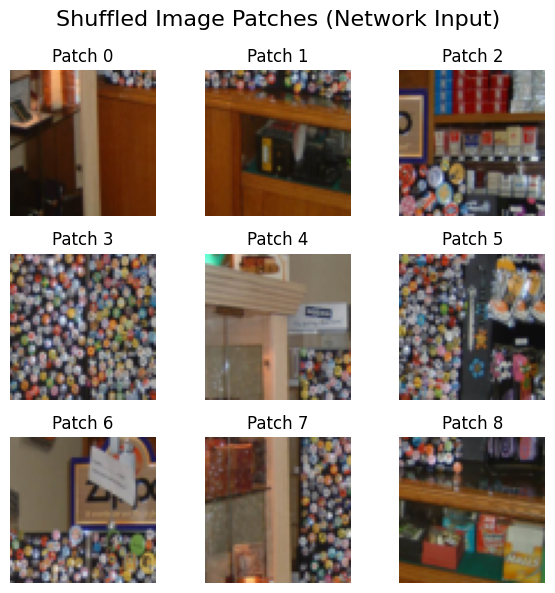

In [11]:
import torchvision.transforms.functional as F

# Initialize and setup the DataModule
data_module = DeepPermNetDataModule(batch_size=1)
data_module.setup()

# Grab one batch from the training dataloader
train_loader = data_module.train_dataloader()
shuffled_patches, target_permutation = next(iter(train_loader))

# Squeeze out the batch dimension
shuffled_patches = shuffled_patches.squeeze(0)
target_permutation = target_permutation.squeeze(0)

# Plot the 9 shuffled patches
print(f"Target Permutation (Indices): {target_permutation.tolist()}")

fig, axes = plt.subplots(3, 3, figsize=(6, 6))
axes = axes.flatten()

for i in range(9):
    # Convert tensor patch back to PIL image for plotting
    patch_img = F.to_pil_image(shuffled_patches[i])
    axes[i].imshow(patch_img)
    axes[i].axis('off')
    axes[i].set_title(f"Patch {i}")

plt.suptitle("Shuffled Image Patches (Network Input)", fontsize=16)
plt.tight_layout()
plt.show()

# Training

The training phase of **DeepPermNet** teaches the model to deduce the exact sequence used to shuffle the image patches. Because the network must predict a mathematical permutation, the architecture relies on two specialized components:

### 1. The Siamese Feature Extractor
The core architecture is a **shared-weight Convolutional Neural Network (CNN)**. Instead of looking at the whole shuffled image at once, the network processes each of the 9 patches independently through the exact same convolutional layers (a Siamese architecture). This forces the network to learn robust, universal patch features. Once the features for all 9 patches are extracted, they are flattened, concatenated, and passed through fully connected (dense) layers to output a raw $9 \times 9$ matrix of predictions.

### 2. The Differentiable Sinkhorn Layer
The biggest challenge in this task is that standard permutation matrices are discrete (strict grids of 0s and 1s), making them impossible to optimize using standard gradient descent.

To bridge this gap, the network passes its raw $9 \times 9$ output through a custom **Sinkhorn Layer**. This layer applies the Sinkhorn algorithm, which repeatedly normalizes the rows and columns of the matrix. After several iterations, this forces the output to become a **doubly-stochastic matrix** (a continuous matrix where every row and column naturally sums to 1).

### Optimization
Because the Sinkhorn layer provides a continuous, differentiable approximation of a permutation, we can train the entire network end-to-end. We calculate the **Mean Squared Error (MSE) loss** between the network's continuous doubly-stochastic output and the ground-truth 1/0 permutation matrix, allowing PyTorch Lightning to update the weights via standard backpropagation.

## The Sinkhorn Layer Implementation

In [13]:
import torch.nn as nn
import torch.nn.functional as F
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint

def sinkhorn_operator(log_alpha, n_iters=20):
    """
    Applies the Sinkhorn iterations to a matrix to approximate a permutation matrix.
    It repeatedly normalizes the rows and columns.
    """
    # Exponentiate to ensure all values are positive
    P = torch.exp(log_alpha)

    # Iterate to normalize rows and columns
    for _ in range(n_iters):
        P = P / P.sum(dim=2, keepdim=True) # Normalize rows
        P = P / P.sum(dim=1, keepdim=True) # Normalize columns
    return P



## PyTorch Lightning Model Definition

In [14]:
class DeepPermNetViT(pl.LightningModule):
    def __init__(self, learning_rate=1e-4, d_model=512, nhead=8, num_layers=4):
        super().__init__()
        self.save_hyperparameters()
        self.learning_rate = learning_rate

        # 1. Siamese CNN Feature Extractor (Extracts local visual features)
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten() # Resulting feature size per patch: 2048
        )

        # 2. Tokenizer Projection (Compress 2048 -> 512 for the Transformer)
        self.token_projection = nn.Linear(2048, d_model)

        # 3. Transformer Encoder (Finds relationships between patches)
        # batch_first=True ensures inputs are (Batch, Sequence, Features)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # 4. Matrix Prediction Head
        # Projects each of the 9 processed tokens to 9 probabilities
        self.prediction_head = nn.Linear(d_model, 9)

    def forward(self, x):
        # x shape: (Batch, 9, 3, 64, 64)
        batch_size, seq_len, channels, height, width = x.size()

        # --- STEP 1: Extract features identically for all 9 patches ---
        x_reshaped = x.view(-1, channels, height, width) # (Batch * 9, 3, 64, 64)
        cnn_features = self.feature_extractor(x_reshaped) # (Batch * 9, 2048)

        # --- STEP 2: Sequence preparation ---
        # Reshape back to a sequence of tokens: (Batch, 9, 2048)
        tokens = cnn_features.view(batch_size, seq_len, -1) 
        
        # Project down to Transformer dimension: (Batch, 9, 512)
        tokens = self.token_projection(tokens) 

        # --- STEP 3: Self-Attention ---
        # The transformer figures out how the patches relate to each other
        transformer_out = self.transformer(tokens) # (Batch, 9, 512)

        # --- STEP 4: Prediction ---
        # Map the 512 features of each token to 9 target locations
        matrix_logits = self.prediction_head(transformer_out) # (Batch, 9, 9)

        # Apply the Sinkhorn layer to approximate a discrete permutation matrix
        predicted_permutation = sinkhorn_operator(matrix_logits)

        return predicted_permutation

    def calculate_loss(self, predicted_matrix, target_indices):
        # Convert index sequences into actual 9x9 one-hot permutation matrices.
        target_matrix = F.one_hot(target_indices, num_classes=9).float()

        # Mean Squared Error
        loss = F.mse_loss(predicted_matrix, target_matrix)
        return loss

    def training_step(self, batch, batch_idx):
        shuffled_patches, target_permutation = batch
        predicted_matrix = self(shuffled_patches)

        loss = self.calculate_loss(predicted_matrix, target_permutation)
        self.log('train_loss', loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        shuffled_patches, target_permutation = batch
        predicted_matrix = self(shuffled_patches)

        loss = self.calculate_loss(predicted_matrix, target_permutation)
        self.log('val_loss', loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.learning_rate)

## Training Launch

In [15]:
# 1. Initialize the DataModule (from your previous code)
# Using a smaller batch size to prevent Colab RAM/VRAM issues
data_module = DeepPermNetDataModule(batch_size=32) 

# 2. Initialize the Upgraded Transformer Model
# We use the new DeepPermNetViT class here instead of DeepPermNet
model = DeepPermNetViT(
    learning_rate=1e-4,
    d_model=512,       # You can tweak these Transformer hyperparameters
    nhead=8, 
    num_layers=4
)

# 3. Setup PyTorch Lightning Trainer
trainer = Trainer(
    max_epochs=15,           # Train for 5 epochs to start
    accelerator='auto',     # Automatically uses GPU if available in Colab
    devices=1,
    log_every_n_steps=10    # Update the progress bar frequently
)

# 4. Start Training!
print("Starting DeepPermNet-ViT Training...")
trainer.fit(model, datamodule=data_module)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Starting DeepPermNet-ViT Training...


2026-06-05 05:22:08.018023: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780636928.248782      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780636928.317138      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780636928.865956      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780636928.865988      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780636928.865991      58 computation_placer.cc:177] computation placer alr

┏━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name              ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ feature_extractor │ Sequential         │  240 K │ train │     0 │
│ 1 │ token_projection  │ Linear             │  1.0 M │ train │     0 │
│ 2 │ transformer       │ TransformerEncoder │ 12.6 M │ train │     0 │
│ 3 │ prediction_head   │ Linear             │  4.6 K │ train │     0 │
└───┴───────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 13.9 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 13.9 M                                                                                               
Total estimated model params size (MB): 55.616                                                                     
Modules in train mode: 58                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

`Trainer.fit` stopped: `max_epochs=15` reached.


# Evaluation & Visualization

Now that **DeepPermNet** is trained, let's see it in action! In this section, we will:
1. Grab a fresh batch of shuffled images from the validation set (images the model has never seen).
2. Pass them through the model to get the predicted permutation matrix.
3. Convert that continuous mathematical matrix back into discrete patch positions using `argmax`.
4. Visually compare three states:
   * **The Input:** The shuffled $3 \times 3$ grid.
   * **The Prediction:** The grid as reassembled by the model's predictions.
   * **The Ground Truth:** The perfect, original image layout.

Evaluating accuracy on freshly re-shuffled validation data...
Patch-level Accuracy over 20 batches: 95.64%

Generating visualizations for 7 sample images...


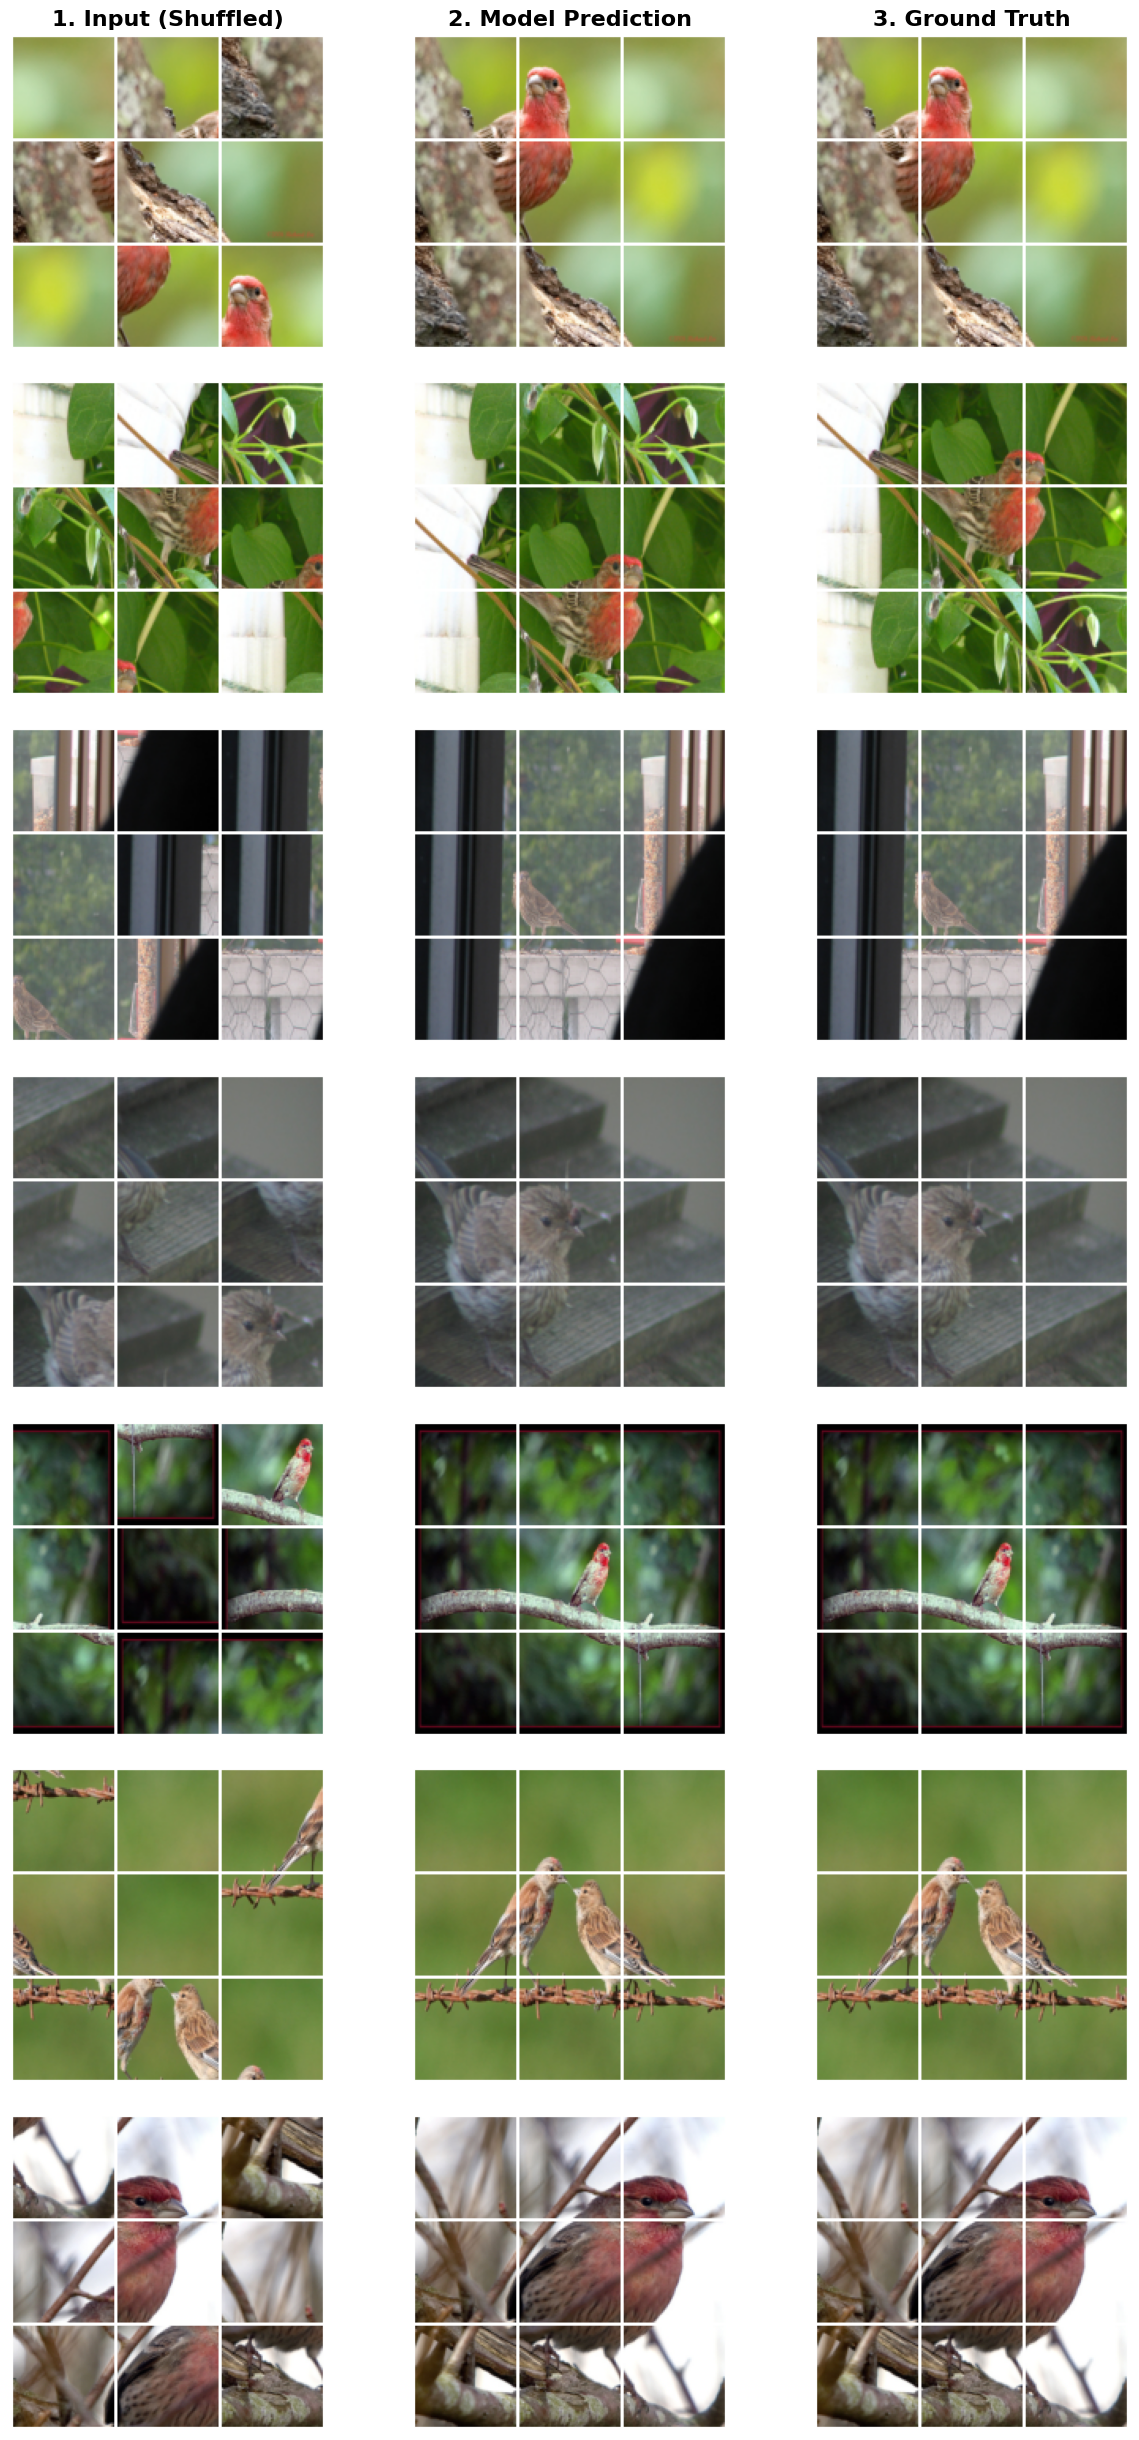

In [18]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

# 1. Set model to evaluation mode
model.eval()

# =======================================================
# PART 1: Calculate Accuracy on a Subset of Eval Data
# =======================================================
print("Evaluating accuracy on freshly re-shuffled validation data...")
num_eval_batches = 20  # Adjust this to test more or fewer batches
correct_patches = 0
total_patches = 0

val_loader = data_module.val_dataloader()

with torch.no_grad():
    for batch_idx, (old_shuffled_patches, old_target_permutation) in enumerate(val_loader):
        if batch_idx >= num_eval_batches:
            break
            
        batch_size = old_shuffled_patches.size(0)
        device = old_shuffled_patches.device
        
        # Create empty tensors to hold our newly shuffled data
        new_shuffled_patches = torch.empty_like(old_shuffled_patches)
        new_target_permutation = torch.empty_like(old_target_permutation)
        
        # Explicitly re-shuffle every image in the current batch
        for b in range(batch_size):
            # A. Un-shuffle: Recover the perfectly ordered patches
            ordered_patches = torch.empty_like(old_shuffled_patches[b])
            ordered_patches[old_target_permutation[b]] = old_shuffled_patches[b]
            
            # B. Generate a brand new random permutation (0 to 8)
            new_perm = torch.randperm(9, device=device)
            
            # C. Re-shuffle: Scramble the patches using this new sequence
            new_shuffled_patches[b] = ordered_patches[new_perm]
            new_target_permutation[b] = new_perm
            
        # Predict the doubly-stochastic matrix using the NEW patches
        predicted_matrix = model(new_shuffled_patches)
        
        # Get the discrete predicted indices (argmax across the last dimension)
        # Shape goes from (Batch, 9, 9) -> (Batch, 9)
        predicted_indices = torch.argmax(predicted_matrix, dim=2)
        
        # Calculate how many patches were placed in the exact right spot
        correct_patches += (predicted_indices == new_target_permutation).sum().item()
        total_patches += new_target_permutation.numel() # Batch size * 9 patches

accuracy = (correct_patches / total_patches) * 100
print(f"Patch-level Accuracy over {num_eval_batches} batches: {accuracy:.2f}%\n")


# =======================================================
# PART 2: Visualize 7 Sample Images
# =======================================================
print("Generating visualizations for 7 sample images...")

# Grab a single fresh batch. Because of how the Dataset class is written, 
# these images are newly shuffled every time they are loaded!
shuffled_patches, target_permutation = next(iter(val_loader))

# Extract exactly 7 samples from the batch
num_samples = 7
sample_patches = shuffled_patches[:num_samples] # Shape: (7, 9, 3, 64, 64)
target_indices = target_permutation[:num_samples] # Shape: (7, 9)

# Perform Inference on all 7 samples at once
with torch.no_grad():
    predicted_matrix = model(sample_patches)
    predicted_indices = torch.argmax(predicted_matrix, dim=2)

# Helper function to reorder patches and stitch them into one beautiful image
def create_grid_image(patches, indices):
    # Create a blank canvas of 9 black patches (prevents crashing if model makes a mistake)
    ordered_patches = torch.zeros_like(patches)
    assigned_positions = set()

    for current_pos, target_pos in enumerate(indices.tolist()):
        # Only place the patch if the target position hasn't been taken yet
        if target_pos not in assigned_positions:
            ordered_patches[target_pos] = patches[current_pos]
            assigned_positions.add(target_pos)
        
    # Magic step: Use PyTorch's make_grid to stitch the 9 patches into a single 3x3 image
    grid_img = make_grid(ordered_patches, nrow=3, padding=2, pad_value=1.0)
    
    # Convert from PyTorch format (C, H, W) to Matplotlib format (H, W, C)
    return grid_img.permute(1, 2, 0).cpu().numpy()

# Set up the Matplotlib Figure (7 rows, 3 columns)
fig, axes = plt.subplots(num_samples, 3, figsize=(12, 3.5 * num_samples))

for i in range(num_samples):
    patches_sq = sample_patches[i] # Shape: (9, 3, 64, 64)
    target_seq = target_indices[i]
    pred_seq = predicted_indices[i]
    
    # The "Input" is just the patches in their raw 0-8 order
    input_seq = torch.arange(9)
    
    # Plot 1: The Input (Shuffled)
    axes[i, 0].imshow(create_grid_image(patches_sq, input_seq))
    axes[i, 0].axis('off')
    if i == 0: axes[i, 0].set_title("1. Input (Shuffled)", fontsize=16, fontweight='bold')

    # Plot 2: The Model's Prediction
    axes[i, 1].imshow(create_grid_image(patches_sq, pred_seq))
    axes[i, 1].axis('off')
    if i == 0: axes[i, 1].set_title("2. Model Prediction", fontsize=16, fontweight='bold')

    # Plot 3: The Ground Truth (Correct Order)
    axes[i, 2].imshow(create_grid_image(patches_sq, target_seq))
    axes[i, 2].axis('off')
    if i == 0: axes[i, 2].set_title("3. Ground Truth", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()

# xPORT

In [22]:
# Save the standard PyTorch weights
torch.save(model.state_dict(), 'deep_perm_net.pth')

# OR: Export to ONNX
dummy_input = torch.randn(1, 9, 3, 64, 64)
torch.onnx.export(model, dummy_input, "deep_perm_net.onnx")

W0605 06:23:58.427000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0605 06:23:58.429000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0605 06:23:58.431000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0605 06:23:58.433000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `DeepPermNetViT([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DeepPermNetViT([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.10.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"x"<FLOAT,[1,9,3,64,64]>
            ),
            outputs=(
                %"div_39"<FLOAT,[1,9,9]>
            ),
            initializers=(
                %"feature_extractor.0.weight"<FLOAT,[32,3,3,3]>{TorchTensor(...)},
                %"feature_extractor.0.bias"<FLOAT,[32]>{TorchTensor(...)},
                %"feature_extractor.3.weight"<FLOAT,[64,32,3,3]>{TorchTensor(...)},
                %"feature_extractor.3.bias"<FLOAT,[64]>{TorchTensor(...)},
                %"feature_extractor.6.weight"<FLOAT,[128,64,3,3]>{TorchTensor(...)},
                %"feature_extractor.6.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"feature_extractor.9.weight"<FLO